<a href="https://colab.research.google.com/github/tanishka-trivedi/PRML-assignments/blob/main/Assignment04_soln.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Assignment-04</h1>

<p>Name: Tanishka Neeraj Trivedi</p>
<p>Roll no. : B24EE1080</p>

### Part-A:-

<h4>Decision Trees [use library]</h4>

<p>1. Perform exploratory analysis i.e., evaluating data distribution, printing
feature shape, class distribution. </p>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
df=pd.read_csv('breast_cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [ ]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [ ]:

df.shape

(569, 33)

In [ ]:
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("\nFeature Names:\n", df.columns)
print("\nClass Distribution:\n", df['diagnosis'].value_counts())
print("\nStatistical Summary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())


Feature Names:
 Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Class Distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64

Statistical Summary:
         diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.8891

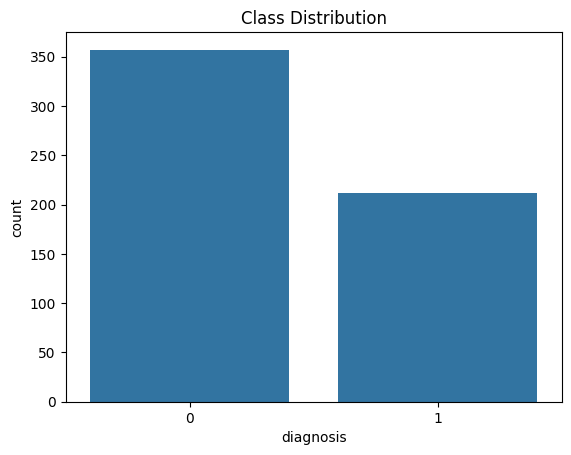

In [ ]:
sns.countplot(x='diagnosis', data=df)
plt.title("Class Distribution")
plt.show()

In [ ]:
print("\nClass Distribution:\n", df['diagnosis'].value_counts())


Class Distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

<h5>Exploratory Data Analysis:</h5>
<p>EDA is performed to understand the dataset before applying machine learning models.
In this dataset:</p>

<p>The id column is removed as it does not contribute to prediction.
The target variable diagnosis is converted:
Malignant (M) → 1
Benign (B) → 0
The dataset contains 30 numerical features.
Class distribution is checked to detect imbalance.
Statistical summary helps understand feature ranges.
Missing values are checked to ensure data quality.</p>

<p>2. Implement Impurity measures i.e., Gini index and entropy</p>

In [ ]:
def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return 1 - np.sum(prob**2)

def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return -np.sum(prob * np.log2(prob + 1e-9))

<p>Impurity Measures: Decision trees use impurity measures to decide how good a split is.</p>

<h1>Gini Index vs Entropy</h1>

<h2>Gini Index</h2>
<p>
    Gini = 1 − ∑ (p<sub>i</sub>)<sup>2</sup>
</p>
<ul>
    <li>Measures probability of misclassification</li>
    <li>Faster to compute</li>
</ul>

<h2>Entropy</h2>
<p>
    Entropy = − ∑ p<sub>i</sub> log<sub>2</sub>(p<sub>i</sub>)
</p>
<ul>
    <li>Measures randomness in data</li>
    <li>Higher entropy → more disorder</li>
</ul>

<p>
    👉 A pure node has impurity = 0.
</p>

<p>3. Information Gain:<br>
A. For each feature, try possible thresholds and compute impurity
reduction<br>
B. Return best feature and threshold</p>

In [ ]:
#information gain:
def information_gain(X_column, y, threshold, impurity_func):
    left = y[X_column <= threshold]
    right = y[X_column > threshold]

    if len(left) == 0 or len(right) == 0:
        return 0

    parent = impurity_func(y)

    n = len(y)
    n_l, n_r = len(left), len(right)

    child = (n_l/n)*impurity_func(left) + (n_r/n)*impurity_func(right)

    return parent - child

In [ ]:
def best_split(X, y, impurity_func):
    best_feature, best_threshold, best_gain = None, None, -1

    for i in range(X.shape[1]):
        values = np.unique(X[:, i])

        for t in values:
            gain = information_gain(X[:, i], y, t, impurity_func)

            if gain > best_gain:
                best_feature = i
                best_threshold = t
                best_gain = gain

    return best_feature, best_threshold, best_gain

<p>Information Gain measures how much impurity decreases after a split.</p>
<p>Try all features and thresholds,
Choose split with maximum gain,
Helps build optimal decision tree</p>

<p>4. Implement the decision tree (using library) in order to create a
generalized classification algorithm (that does not overfit). Visualize the
decision tree and its boundary</p>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_split=5)

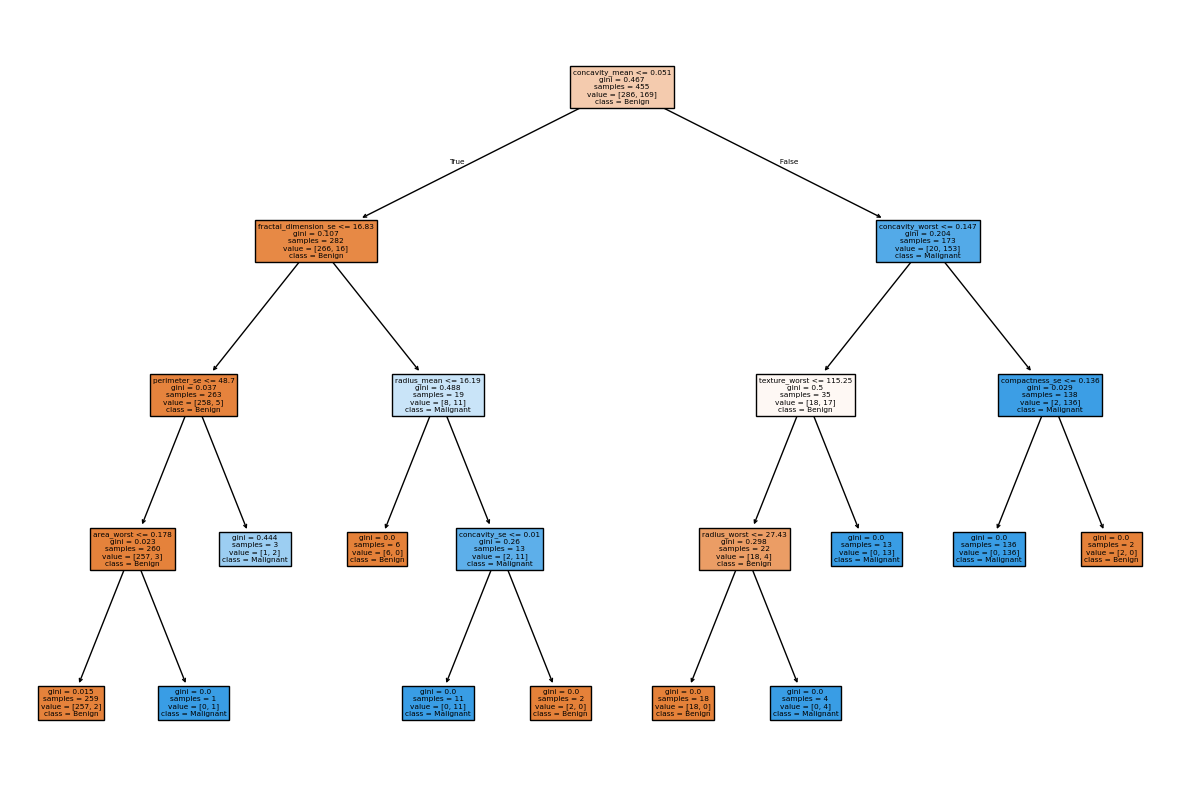

In [ ]:
#visualization
plt.figure(figsize=(15,10))
plot_tree(model,
          feature_names=df.columns[:-1],
          class_names=['Benign', 'Malignant'],
          filled=True)
plt.show()

<p>A decision tree splits data based on feature thresholds.<br>
At each node, the best split is chosen using impurity reduction.<br>
Overfitting is controlled using:<br>
1. max_depth<br>
2. min_samples_split<br>
The model learns interpretable rules for classification.</p>

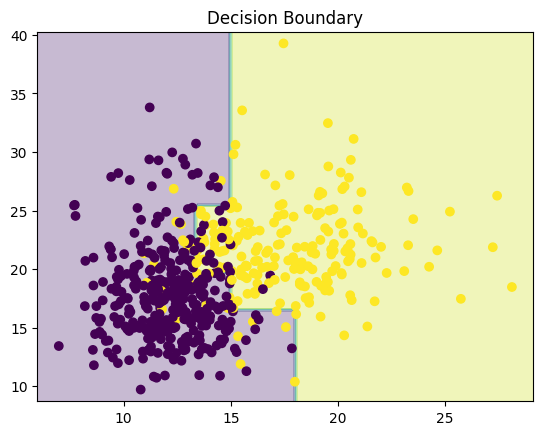

In [ ]:
# boundary visualization
X2 = X[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = DecisionTreeClassifier(max_depth=4)
model2.fit(X_train2, y_train2)

# Meshgrid
x_min, x_max = X2[:, 0].min()-1, X2[:, 0].max()+1
y_min, y_max = X2[:, 1].min()-1, X2[:, 1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y)
plt.title("Decision Boundary")
plt.show()

<p>5. Prediction and Evaluation</p>
<p>A. Predict labels for test data<br>
B. Compute accuracy. Visualize the results via confusion matrix</p>

Accuracy: 0.9385964912280702


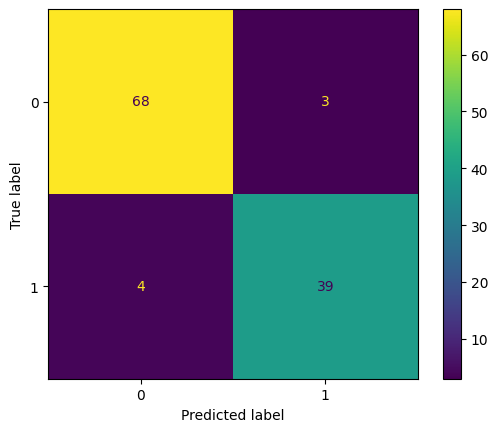

In [ ]:

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

<p>Prediction and Evaluation:

The trained model predicts labels for test data.
Accuracy measures overall correctness.
Confusion matrix provides detailed evaluation:<br>
True Positives<br>
True Negatives<br>
False Positives<br>
False Negatives<br>
Helps understand model performance beyond accuracy.

<h3>Conclusion:</h3>
<p>The decision tree model successfully classifies breast cancer cases using feature-based splits. Gini index and entropy help measure impurity, while information gain selects optimal splits. Proper tuning prevents overfitting, resulting in a reliable and interpretable model.</p>

### Part-B:-

<h4>Support Vector Machines [use library]</h4>

<p>1.Data Preparation Pipeline:<br>
A. Split dataset into train/test sets<br>
B. Perform feature scaling using StandardScaler<br>
C. Verify shapes of processed data</p>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('breast_cancer_data.csv')
df = df.drop(columns=['id'], errors='ignore')
df = df.drop(columns=['Unnamed: 32'], errors='ignore')

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


print("NaNs before:", X.isnull().sum().sum())
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
print("NaNs after:", np.isnan(X).sum())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NaNs before: 0
NaNs after: 0


In [ ]:
print("Any NaN in train:", np.isnan(X_train_scaled).sum())
print("Any NaN in test:", np.isnan(X_test_scaled).sum())

#check nans as svm doesnt handle those cases

Any NaN in train: 0
Any NaN in test: 0


<p> Here, we have first cleaned the data by removing the column id which was of no use. Did the numerical encoding. The dataset is split into training and testing sets (80-20 split).
Feature scaling is performed using StandardScaler:
Mean = 0
Standard deviation = 1
Scaling is essential for SVM because it is distance-based.
Shapes are verified to ensure correct preprocessing.</p>

<p>2. Train an SVM with linear kernel [use library]. Showcase the number of
support vectors, model coefficients (if available).</p>

In [ ]:

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_scaled, y_train)

print("Number of support vectors:", svm_linear.n_support_)
print("\nCoefficients:\n", svm_linear.coef_)
print("\nIntercept:", svm_linear.intercept_)

Number of support vectors: [20 16]

Coefficients:
 [[ 0.3547182   0.05407918  0.27841613  0.22435288 -0.05513569 -0.75410654
   0.65163147  1.41650461 -0.15897     0.13477067  1.01381006 -0.37168265
   0.20192331  0.77440381  0.33479408 -0.36820645 -0.24462673  0.18436516
  -0.39191077 -0.60305658  0.59782035  1.1928433   0.11793292  0.55025799
   0.23050889 -0.15264298  0.75127862  0.11355058  0.80239445  0.52539728]]

Intercept: [-0.01175014]


Linear SVM:

SVM finds a hyperplane that separates classes with maximum margin.
Linear kernel assumes data is linearly separable.
Support vectors are:
Critical data points closest to decision boundary
The model coefficients represent the hyperplane equation.

Only support vectors influence the model.

<p>3. Model Evaluation:<br>
A. Predict on test set<br>
B. Compute accuracy and confusion matrix</p>

Linear SVM Accuracy: 0.956140350877193


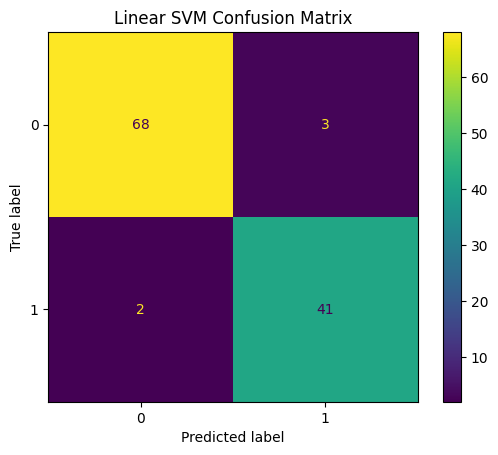

In [ ]:
y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)
print("Linear SVM Accuracy:", acc_linear)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_linear)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.show()

<p>Accuracy measures correct predictions.
Confusion matrix gives detailed classification results.</p>

<p>The trained SVM predicts labels on unseen test data.
Accuracy measures overall correctness.</p>

<p>4. Kernel Comparison:<br>
A. Train SVM with RBF kernel.<br>
B. Compare the accuracy of the RBF kernel with the linear kernel.</p>

In [ ]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("Linear Accuracy:", acc_linear)
print("RBF Accuracy:", acc_rbf)

Linear Accuracy: 0.956140350877193
RBF Accuracy: 0.9824561403508771


<p>Linear kernel works for linearly separable data.<br>
RBF kernel maps data into higher dimensions.
RBF handles complex, non-linear boundaries.
In most real-world cases, RBF performs better.</p>

<p>5. Hyperparameter Tuning:</p>
<p>A. Experiment with parameters i.e., C (regularization) and gamma (for
RBF)<br>
B. Create a table showing parameter values vs accuracy.</p>

In [ ]:
results = []

C_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]

for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)

        results.append((C, gamma, acc))

results_df = pd.DataFrame(results, columns=['C', 'gamma', 'accuracy'])
print(results_df)

      C  gamma  accuracy
0   0.1   0.01  0.964912
1   0.1   0.10  0.947368
2   0.1   1.00  0.622807
3   1.0   0.01  0.964912
4   1.0   0.10  0.964912
5   1.0   1.00  0.631579
6  10.0   0.01  0.982456
7  10.0   0.10  0.964912
8  10.0   1.00  0.631579


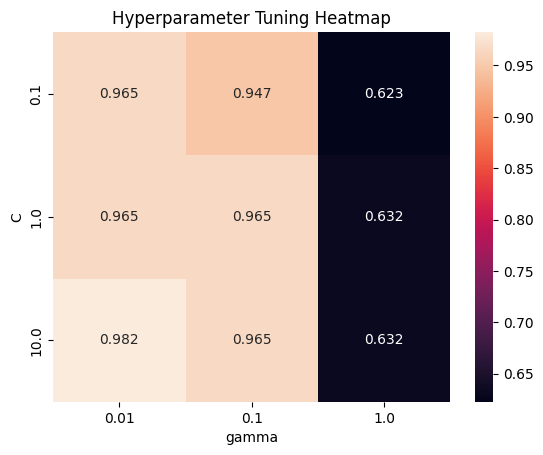

In [ ]:
#visualization
pivot = results_df.pivot(index='C', columns='gamma', values='accuracy')

sns.heatmap(pivot, annot=True, fmt=".3f")
plt.title("Hyperparameter Tuning Heatmap")
plt.show()

<p>Hyperparameter Tuning:

C controls margin:
Small C → wider margin (more regularization)
Large C → less regularization<br>
gamma controls influence of points:
Small gamma → smoother boundary
Large gamma → complex boundary<br>
Grid search is used to find best combination.
Results are tabulated and visualized.

<h3>Conclusion:</h3>
<p>Support Vector Machines effectively classify the breast cancer dataset by maximizing the margin between classes. Feature scaling significantly improves performance. Linear SVM works well for simple patterns, while RBF kernel captures complex relationships. Hyperparameter tuning further enhances model accuracy.</p>

### Overall Conclusion:

<p>In this assignment, machine learning techniques including Decision Trees and Support Vector Machines were applied to the Breast Cancer Wisconsin dataset to perform classification of tumors as benign or malignant.

Through exploratory data analysis, the dataset was cleaned and preprocessed by handling missing values, encoding categorical variables, and scaling features. Decision Trees provided an interpretable model by using impurity measures such as Gini index and entropy, along with information gain to determine optimal splits. Proper tuning helped in avoiding overfitting while maintaining good accuracy.

Support Vector Machines demonstrated strong performance due to their ability to maximize the margin between classes. Feature scaling and handling of missing values were crucial for effective training. The comparison between linear and RBF kernels showed that the RBF kernel can better capture complex, non-linear patterns in the data. Hyperparameter tuning further improved the models performance.

Overall, both models performed well on the dataset, with SVM generally achieving higher accuracy, while Decision Trees offered better interpretability. This highlights the trade-off between model performance and explainability in machine learning.</p>